In [ ]:
# Implementation of Simple Linear Regression
# House Price Prediction Using Simple Linear Regression

##Step 1: Import Required Libraries

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

##Step 2: Load and Explore the Dataset (EDA)

In [ ]:
# ============================================
# 2. Load the California Housing dataset
# ============================================
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# View the first few rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# View the last few rows
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [ ]:
# Check number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 9)


In [ ]:
# View column names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [ ]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [ ]:
# Check basic information
df.info()
# It tells you:

# Number of rows
# Column names
# Non-null values
# Data types
# Memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [ ]:
# To check whether any missing value exists in the entire dataset:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# You can also get a simple Yes/No answer:
if df.duplicated().sum() > 0:
    print("Duplicate rows exist.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [ ]:
# Check categorical columns
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
[]


In [ ]:
# You can also check numerical columns:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [ ]:
# Check unique values

In [ ]:
print("Number of unique values in each column:")
print(df.nunique())
# This helps identify columns with:

# Very few unique values
# Many unique values
# Potential categorical columns

Number of unique values in each column:
MedInc         12928
HouseAge          52
AveRooms       19392
AveBedrms      14233
Population      3888
AveOccup       18841
Latitude         862
Longitude        844
MedHouseVal     3842
dtype: int64


In [ ]:
# Statistical summary
display(df.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
# Check target variable
# Our target is:
target = "MedHouseVal"
# Check its basic statistics:
print(df["MedHouseVal"].describe())

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


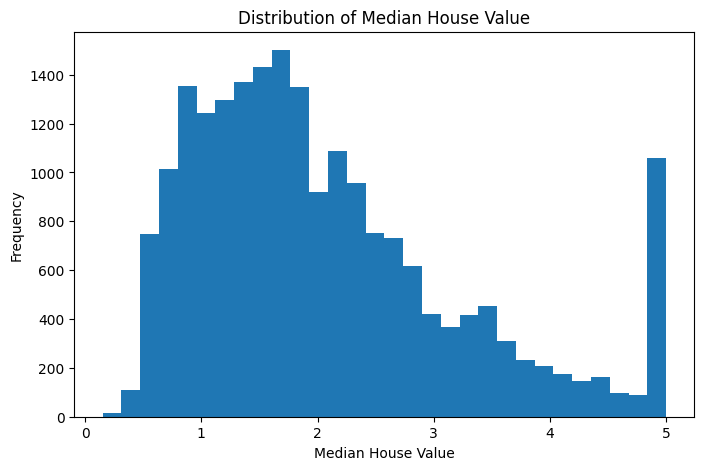

In [ ]:
# You can also visualize it:
plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseVal"], bins=30)

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")

plt.show()
#This helps us understand how the target values are distributed.

In [ ]:
# Check correlation
# Correlation is very useful for regression
correlation = df.corr(numeric_only=True)
display(correlation)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [ ]:
# To see which features are most correlated with the target:
print(
    correlation["MedHouseVal"]
    .sort_values(ascending=False)
)
# This gives an idea of which numerical variables have stronger or weaker linear relationships with house value.
# Remember: correlation does not prove causation.

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


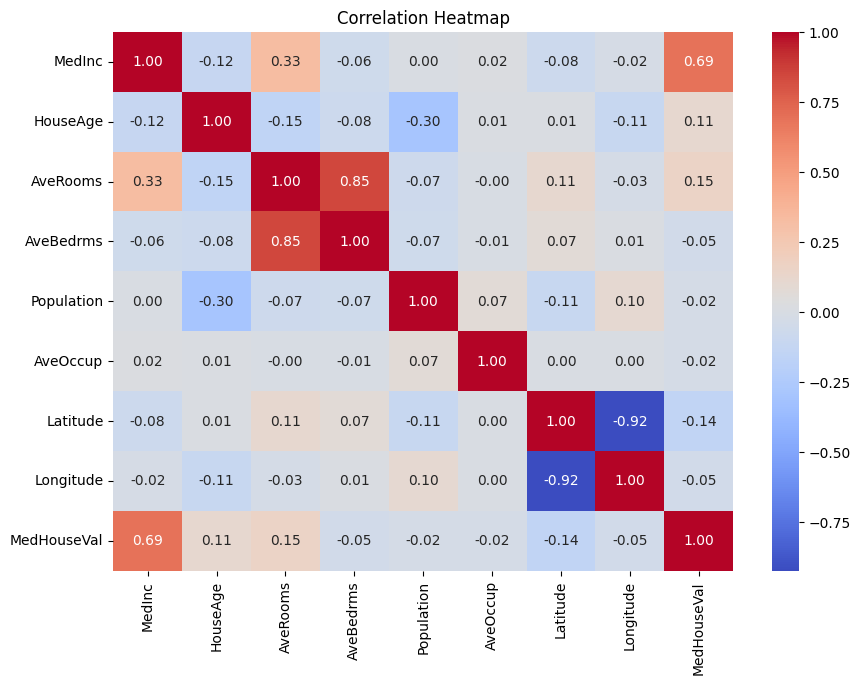

In [ ]:
# Visualize correlation using a heatmap
# For EDA, this is very useful:
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

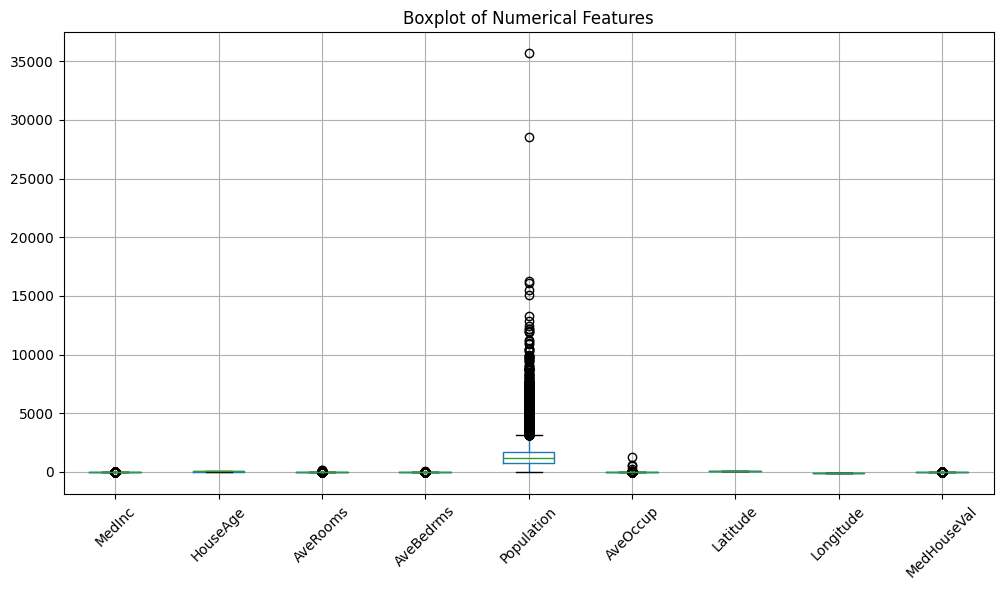

In [ ]:
# Check for outliers using boxplots
plt.figure(figsize=(12, 6))

df.boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()
# Boxplots can help us identify potential outliers.

## Step 3: Defining featurers (X) and target (y)

In [ ]:
# Separate features (X) and target (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [ ]:
# Check target and features
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 8)
y shape: (20640,)


In [ ]:
display(X.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
display(y.head())

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


##Step 4. Splitting data across training and testing set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Check the sizes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


In [ ]:
# What does random_state=42 mean?
# random_state=42
# makes the split reproducible.

# If you run the code again, you get the same train/test split.

##Step 5: Training the model

In [ ]:
# Now we create our Linear Regression model.
model = LinearRegression()


In [ ]:
# At this point, we have created the model, but it hasn't learned anything yet.
# Now train it:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# The model learns coefficients for each feature.
# You can see them:
print("Coefficients:")
print(model.coef_)
# And the intercept:
print("Intercept:")
print(model.intercept_)

Coefficients:
[ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept:
-37.02327770606409


## Step 6: Evaluating the Model on the Test Data (Prediction)

In [ ]:
# Now that the model has learned from the training data, give it the test data.
y_pred = model.predict(X_test)
# y_pred contains the house values predicted by the model.

In [ ]:
# Check the first 10 predictions:
print("Predicted values:")
print(y_pred[:10])

Predicted values:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [ ]:
# Compare them with actual values:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

display(comparison)

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## Evaluation Metrics:
# Now we need to answer:
# How well did our model perform?
# For regression, two important metrics are: mse and r squared

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 0.5558915986952444
Root Mean Squared Error: 0.7455813830127764
R² Score: 0.5757877060324508


# Visualization
# Now we can visualize Actual vs Predicted values.

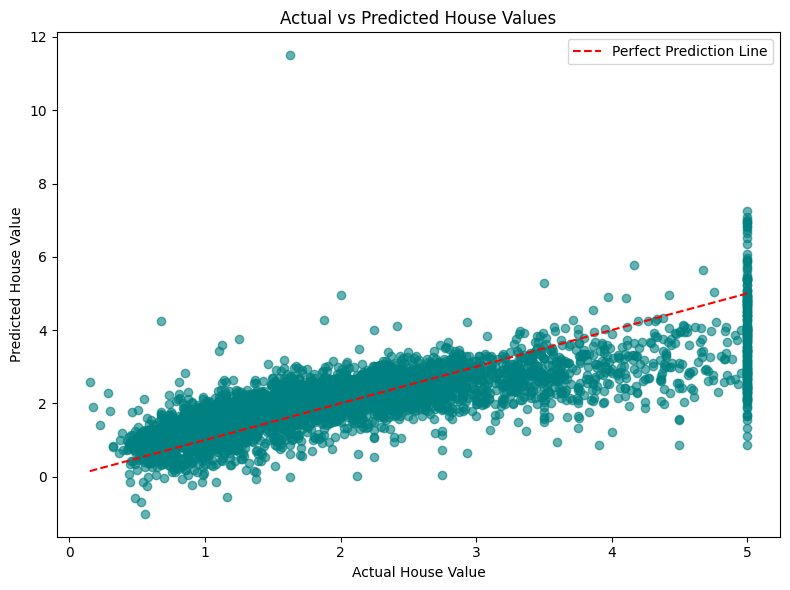

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,
    color="teal"
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction Line"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Testing on the New Unseen Data

In [ ]:
new_house1 = pd.DataFrame([{
    "MedInc": 5.0,
    "HouseAge": 20,
    "AveRooms": 6.0,
    "AveBedrms": 1.0,
    "Population": 1000,
    "AveOccup": 3.0,
    "Latitude": 34.05,
    "Longitude": -118.25
}])

prediction = model.predict(new_house1)[0]
print(f"Predicted House Price: ${prediction * 100000:,.2f}")

Predicted House Price: $243,722.28


In [ ]:
new_house2 = pd.DataFrame([{
    "MedInc": 3.0,
    "HouseAge": 25,
    "AveRooms": 7.0,
    "AveBedrms": 2.0,
    "Population": 1500,
    "AveOccup": 3.0,
    "Latitude": 34.05,
    "Longitude": -118.25
}])

prediction = model.predict(new_house2)[0]
print(f"Predicted House Price: ${prediction * 100000:,.2f}")

Predicted House Price: $224,730.10
